In [1]:
#!pip install datasets evaluate --upgrade
#!python -m spacy download fr_core_news_sm

# Preparing Data


In [76]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import spacy
import datasets
import tqdm
import evaluate
import pandas as pd
import csv
import time
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import Dataset

In [3]:
seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [6]:
# !unzip data.zip

Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Italian.txt  
  inflating: data/names/Japanese.txt  
  inflating: data/names/Korean.txt   
  inflating: data/names/Polish.txt   
  inflating: data/names/Portuguese.txt  
  inflating: data/names/Russian.txt  
  inflating: data/names/Scottish.txt  
  inflating: data/names/Spanish.txt  
  inflating: data/names/Vietnamese.txt  


In [7]:
def load_and_clean_data(file_path):
    df = pd.read_csv(file_path, sep='\t', names=['src', 'trg'], engine='python', quoting=csv.QUOTE_NONE)
    df['src'] = df['src'].str.strip()
    df['trg'] = df['trg'].str.strip()
    return df

df = load_and_clean_data('/content/data/eng-fra.txt')
print(df.head())

     src         trg
0    Go.        Va !
1   Run!     Cours !
2   Run!    Courez !
3   Wow!  Ça alors !
4  Fire!    Au feu !


In [8]:
class TranslationDataset(Dataset):
    def __init__(self, df):
        self.examples = [
            {"en": row["src"], "fr": row["trg"]}
            for _, row in df.iterrows()
        ]

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

train_df = df.sample(frac=0.8, random_state=42)
remaining_df = df.drop(train_df.index)
val_df = remaining_df.sample(frac=0.5, random_state=42)
test_df = remaining_df.drop(val_df.index)

train_data = TranslationDataset(train_df)
validation_data = TranslationDataset(val_df)
test_data = TranslationDataset(test_df)

In [9]:
train_data[0]

{'en': 'The wind was so strong, we were nearly blown off the road.',
 'fr': 'Le vent était tellement fort que nous avons presque été poussés en dehors de la route.'}

In [10]:
validation_data[0]

{'en': "Don't cross this bridge.", 'fr': 'Ne traversez pas ce pont.'}

In [11]:
test_data[0]

{'en': 'Help!', 'fr': "À l'aide\u202f!"}

In [13]:
en_nlp = spacy.load("en_core_web_sm")
fr_nlp = spacy.load("fr_core_news_sm")

In [14]:
string = "What a lovely day it is today!"

[token.text for token in en_nlp.tokenizer(string)]

['What', 'a', 'lovely', 'day', 'it', 'is', 'today', '!']

In [15]:
def tokenize_example(example, en_nlp, fr_nlp, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in en_nlp.tokenizer(example["en"])][:max_length]
    fr_tokens = [token.text for token in fr_nlp.tokenizer(example["fr"])][:max_length]

    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        fr_tokens = [token.lower() for token in fr_tokens]

    en_tokens = [sos_token] + en_tokens + [eos_token]
    fr_tokens = [sos_token] + fr_tokens + [eos_token]

    example["en_tokens"] = en_tokens
    example["fr_tokens"] = fr_tokens

    return example

In [16]:
max_length = 1000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "en_nlp": en_nlp,
    "fr_nlp": fr_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data.examples = [tokenize_example(ex, **fn_kwargs) for ex in train_data.examples]
validation_data.examples = [tokenize_example(ex, **fn_kwargs) for ex in validation_data.examples]
test_data.examples  = [tokenize_example(ex, **fn_kwargs) for ex in test_data.examples]

In [17]:
train_data[0]

{'en': 'The wind was so strong, we were nearly blown off the road.',
 'fr': 'Le vent était tellement fort que nous avons presque été poussés en dehors de la route.',
 'en_tokens': ['<sos>',
  'the',
  'wind',
  'was',
  'so',
  'strong',
  ',',
  'we',
  'were',
  'nearly',
  'blown',
  'off',
  'the',
  'road',
  '.',
  '<eos>'],
 'fr_tokens': ['<sos>',
  'le',
  'vent',
  'était',
  'tellement',
  'fort',
  'que',
  'nous',
  'avons',
  'presque',
  'été',
  'poussés',
  'en',
  'dehors',
  'de',
  'la',
  'route',
  '.',
  '<eos>']}

In [18]:
class Vocabulary:
    def __init__(self, special_tokens, unk_token="<unk>"):
        self.special_tokens = special_tokens
        self.unk_token = unk_token
        self.stoi = {}
        self.itos = {}

        for idx, token in enumerate(self.special_tokens):
            self.stoi[token] = idx
            self.itos[idx] = token

        self.unk_idx = self.stoi[self.unk_token]

    def build_vocab(self, tokenized_texts, min_freq):
        counter = Counter()
        for tokens in tokenized_texts:
            counter.update(tokens)

        idx = len(self.stoi)
        for word, freq in counter.items():
            if freq >= min_freq and word not in self.stoi:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def get_itos(self):
        return [self.itos[i] for i in range(len(self.itos))]

    def get_stoi(self):
        return self.stoi

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        if isinstance(token, list):
            return [self.stoi.get(t, self.unk_idx) for t in token]
        return self.stoi.get(token, self.unk_idx)

    def __call__(self, tokens):
        return self.__getitem__(tokens)

    def set_default_index(self, index):
        self.unk_idx = index

    def lookup_indices(self, tokens):
        return [self.stoi.get(token, self.unk_idx) for token in tokens]

    def lookup_tokens(self, indices):
        return [self.itos.get(idx, self.unk_token) for idx in indices]

In [19]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"
special_tokens = [unk_token, pad_token, sos_token, eos_token]

all_en_tokens = []
all_fr_tokens = []

for example in train_data:
    all_en_tokens.append(example["en_tokens"])
    all_fr_tokens.append(example["fr_tokens"])

en_vocab = Vocabulary(special_tokens=special_tokens, unk_token=unk_token)
en_vocab.build_vocab(all_en_tokens, min_freq=min_freq)

fr_vocab = Vocabulary(special_tokens=special_tokens, unk_token=unk_token)
fr_vocab.build_vocab(all_fr_tokens, min_freq=min_freq)

In [20]:
en_vocab.get_itos()[:10]

['<unk>', '<pad>', '<sos>', '<eos>', 'the', 'wind', 'was', 'so', 'strong', ',']

In [25]:
len(en_vocab), len(fr_vocab)

(8219, 12898)

In [29]:
assert en_vocab[unk_token] == fr_vocab[unk_token]
assert en_vocab[pad_token] == fr_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

In [30]:
en_vocab.set_default_index(unk_index)
fr_vocab.set_default_index(unk_index)

In [33]:
tokens = ["i", "love", "watching", "crime", "shows"]

In [34]:
en_vocab.lookup_indices(tokens)

[56, 177, 117, 417, 3147]

In [36]:
train_data[0]

{'en': 'The wind was so strong, we were nearly blown off the road.',
 'fr': 'Le vent était tellement fort que nous avons presque été poussés en dehors de la route.',
 'en_tokens': ['<sos>',
  'the',
  'wind',
  'was',
  'so',
  'strong',
  ',',
  'we',
  'were',
  'nearly',
  'blown',
  'off',
  'the',
  'road',
  '.',
  '<eos>'],
 'fr_tokens': ['<sos>',
  'le',
  'vent',
  'était',
  'tellement',
  'fort',
  'que',
  'nous',
  'avons',
  'presque',
  'été',
  'poussés',
  'en',
  'dehors',
  'de',
  'la',
  'route',
  '.',
  '<eos>']}

In [37]:
for dataset in [train_data, validation_data, test_data]:
    for example in dataset.examples:
        example["en_ids"] = en_vocab.lookup_indices(example["en_tokens"])
        example["fr_ids"] = fr_vocab.lookup_indices(example["fr_tokens"])

In [38]:
en_vocab.lookup_tokens(train_data[0]["en_ids"])

['<sos>',
 'the',
 'wind',
 'was',
 'so',
 'strong',
 ',',
 'we',
 'were',
 'nearly',
 'blown',
 'off',
 'the',
 'road',
 '.',
 '<eos>']

In [39]:
train_data[0]

{'en': 'The wind was so strong, we were nearly blown off the road.',
 'fr': 'Le vent était tellement fort que nous avons presque été poussés en dehors de la route.',
 'en_tokens': ['<sos>',
  'the',
  'wind',
  'was',
  'so',
  'strong',
  ',',
  'we',
  'were',
  'nearly',
  'blown',
  'off',
  'the',
  'road',
  '.',
  '<eos>'],
 'fr_tokens': ['<sos>',
  'le',
  'vent',
  'était',
  'tellement',
  'fort',
  'que',
  'nous',
  'avons',
  'presque',
  'été',
  'poussés',
  'en',
  'dehors',
  'de',
  'la',
  'route',
  '.',
  '<eos>'],
 'en_ids': [2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 4, 15, 16, 3],
 'fr_ids': [2,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  3]}

# Data Loaders

In [40]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [torch.tensor(example["en_ids"], dtype=torch.long) for example in batch]
        batch_fr_ids = [torch.tensor(example["fr_ids"], dtype=torch.long) for example in batch]

        # CHANGED: Added batch_first=False (this forces shape to [seq_len, batch_size])
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index, batch_first=False)
        batch_fr_ids = nn.utils.rnn.pad_sequence(batch_fr_ids, padding_value=pad_index, batch_first=False)

        batch = {
            "en_ids": batch_en_ids,
            "fr_ids": batch_fr_ids,
        }
        return batch

    return collate_fn

In [41]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False
    )
    return data_loader

In [42]:
batch_size = 128

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(validation_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

# Building the Model

In [43]:
class Encoder(nn.Module):
    def __init__(
        self, input_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim, dropout
    ):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, encoder_hidden_dim, bidirectional=True)
        self.fc = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src length, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src length, batch size, embedding dim]
        outputs, hidden = self.rnn(embedded)
        # outputs = [src length, batch size, hidden dim * n directions]
        # hidden = [n layers * n directions, batch size, hidden dim]
        # hidden is stacked [forward_1, backward_1, forward_2, backward_2, ...]
        # outputs are always from the last layer
        # hidden [-2, :, : ] is the last of the forwards RNN
        # hidden [-1, :, : ] is the last of the backwards RNN
        # initial decoder hidden is final hidden state of the forwards and backwards
        # encoder RNNs fed through a linear layer
        hidden = torch.tanh(
            self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        )
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        return outputs, hidden

In [44]:
class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        self.attn_fc = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim, decoder_hidden_dim
        )
        self.v_fc = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        batch_size = encoder_outputs.shape[1]
        src_length = encoder_outputs.shape[0]
        # repeat decoder hidden state src_length times
        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # hidden = [batch size, src length, decoder hidden dim]
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))
        # energy = [batch size, src length, decoder hidden dim]
        attention = self.v_fc(energy).squeeze(2)
        # attention = [batch size, src length]
        return torch.softmax(attention, dim=1)

In [45]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        dropout,
        attention,
    ):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU((encoder_hidden_dim * 2) + embedding_dim, decoder_hidden_dim)
        self.fc_out = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim, output_dim
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch size]
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        input = input.unsqueeze(0)
        # input = [1, batch size]
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, embedding dim]
        a = self.attention(hidden, encoder_outputs)
        # a = [batch size, src length]
        a = a.unsqueeze(1)
        # a = [batch size, 1, src length]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        weighted = torch.bmm(a, encoder_outputs)
        # weighted = [batch size, 1, encoder hidden dim * 2]
        weighted = weighted.permute(1, 0, 2)
        # weighted = [1, batch size, encoder hidden dim * 2]
        rnn_input = torch.cat((embedded, weighted), dim=2)
        # rnn_input = [1, batch size, (encoder hidden dim * 2) + embedding dim]
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        # output = [seq length, batch size, decoder hid dim * n directions]
        # hidden = [n layers * n directions, batch size, decoder hid dim]
        # seq len, n layers and n directions will always be 1 in this decoder, therefore:
        # output = [1, batch size, decoder hidden dim]
        # hidden = [1, batch size, decoder hidden dim]
        # this also means that output == hidden
        assert (output == hidden).all()
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        # prediction = [batch size, output dim]
        return prediction, hidden.squeeze(0), a.squeeze(1)

In [46]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if teacher_forcing_ratio is 0.75 we use teacher forcing 75% of the time
        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        # tensor to store decoder outputs
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        # encoder_outputs is all hidden states of the input sequence, back and forwards
        # hidden is the final forward and backward hidden states, passed through a linear layer
        encoder_outputs, hidden = self.encoder(src)
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        # first input to the decoder is the <sos> tokens
        input = trg[0, :]
        for t in range(1, trg_length):
            # insert input token embedding, previous hidden state and all encoder hidden states
            # receive output tensor (predictions) and new hidden state
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            # output = [batch size, output dim]
            # hidden = [n layers, batch size, decoder hidden dim]
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1
            # input = [batch size]
        return outputs

# Training the Model


In [47]:
input_dim = len(fr_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256
decoder_embedding_dim = 256
encoder_hidden_dim = 512
decoder_hidden_dim = 512
encoder_dropout = 0.5
decoder_dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(encoder_hidden_dim, decoder_hidden_dim)

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    decoder_dropout,
    attention,
)

model = Seq2Seq(encoder, decoder, device).to(device)

In [48]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)


model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(12898, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1536, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(8219, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=8219, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [49]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 26,575,899 trainable parameters


In [50]:
optimizer = optim.Adam(model.parameters())

In [51]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [52]:
TRG_PAD_IDX = fr_vocab.get_stoi()["<pad>"]
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)

In [53]:
def train_fn(model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device):
    model.train()
    epoch_loss = 0
    total_batches = len(data_loader)

    print(f"   [Train] Total batches to process: {total_batches}")

    for i, batch in enumerate(data_loader):
        src = batch["fr_ids"].to(device)
        trg = batch["en_ids"].to(device)

        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg_target = trg[1:].view(-1)

        loss = criterion(output, trg_target)
        loss.backward()

        # Keep clipping off for a moment just to ensure high speed
        # torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()
        epoch_loss += loss.item()

        # FORCE A NEW LINE PRINT EVERY SINGLE BATCH
        print(f"   >>> [Train] Core Engine Active: Completed Batch {i+1}/{total_batches} | Current Loss: {loss.item():.4f}")

    print("\n   [Train] All training batches completed for this epoch.")
    return epoch_loss / total_batches

In [54]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    print(f"   [Eval] Total batches to process: {len(data_loader)}")

    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["fr_ids"].to(device)
            trg = batch["en_ids"].to(device)

            output = model(src, trg, 0)

            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg_target = trg[1:].view(-1)

            loss = criterion(output, trg_target)
            epoch_loss += loss.item()

    print("   [Eval] All evaluation batches completed.")
    return epoch_loss / len(data_loader)

# Training

In [55]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5

best_valid_loss = float("inf")
print(f"Starting execution loop for {n_epochs} Epochs...\n")

for epoch in range(n_epochs):
    start_time = time.time()

    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device,
    )

    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        device,
    )

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(int(end_time - start_time), 60)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "tut3-model.pt")
        print(f" -> Epoch {epoch+1}: Discovered lower loss footprint! Weights stored.")

    print(f"Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}\n")

Streaming output truncated to the last 5000 lines.
   >>> [Train] Core Engine Active: Completed Batch 156/850 | Current Loss: 1.0360
   >>> [Train] Core Engine Active: Completed Batch 157/850 | Current Loss: 0.7429
   >>> [Train] Core Engine Active: Completed Batch 158/850 | Current Loss: 0.9334
   >>> [Train] Core Engine Active: Completed Batch 159/850 | Current Loss: 0.8210
   >>> [Train] Core Engine Active: Completed Batch 160/850 | Current Loss: 0.8612
   >>> [Train] Core Engine Active: Completed Batch 161/850 | Current Loss: 1.0467
   >>> [Train] Core Engine Active: Completed Batch 162/850 | Current Loss: 1.0288
   >>> [Train] Core Engine Active: Completed Batch 163/850 | Current Loss: 1.0116
   >>> [Train] Core Engine Active: Completed Batch 164/850 | Current Loss: 0.7600
   >>> [Train] Core Engine Active: Completed Batch 165/850 | Current Loss: 1.0852
   >>> [Train] Core Engine Active: Completed Batch 166/850 | Current Loss: 0.8666
   >>> [Train] Core Engine Active: Completed Ba

# Evaluating the Model

In [67]:
model.load_state_dict(torch.load("tut3-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

   [Eval] Total batches to process: 107
   [Eval] All evaluation batches completed.
| Test Loss: 1.636 | Test PPL:   5.132 |


In [68]:
def translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            de_tokens = [token.text for token in de_nlp.tokenizer(sentence)]
        else:
            de_tokens = [token for token in sentence]
        if lower:
            de_tokens = [token.lower() for token in de_tokens]
        de_tokens = [sos_token] + de_tokens + [eos_token]
        ids = de_vocab.lookup_indices(de_tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        encoder_outputs, hidden = model.encoder(tensor)
        inputs = en_vocab.lookup_indices([sos_token])
        attentions = torch.zeros(max_output_length, 1, len(ids))
        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, attention = model.decoder(
                inputs_tensor, hidden, encoder_outputs
            )
            attentions[i] = attention
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        en_tokens = en_vocab.lookup_tokens(inputs)
    return en_tokens, de_tokens, attentions[: len(en_tokens) - 1]

In [69]:
def plot_attention(sentence, translation, attention):
    fig, ax = plt.subplots(figsize=(10, 10))
    attention = attention.squeeze(1).numpy()
    cax = ax.matshow(attention, cmap="bone")
    ax.set_xticks(ticks=np.arange(len(sentence)), labels=sentence, rotation=90, size=15)
    translation = translation[1:]
    ax.set_yticks(ticks=np.arange(len(translation)), labels=translation, size=15)
    plt.show()
    plt.close()

In [71]:
sentence = test_data[0]["fr"]
expected_translation = test_data[0]["en"]

sentence, expected_translation

("À l'aide\u202f!", 'Help!')

In [72]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    fr_nlp,
    en_vocab,
    fr_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [73]:
translation

['<sos>', 'help', 'him', '!', '<eos>']

In [74]:
sentence_tokens

['<sos>', 'à', "l'", 'aide', '\u202f', '!', '<eos>']

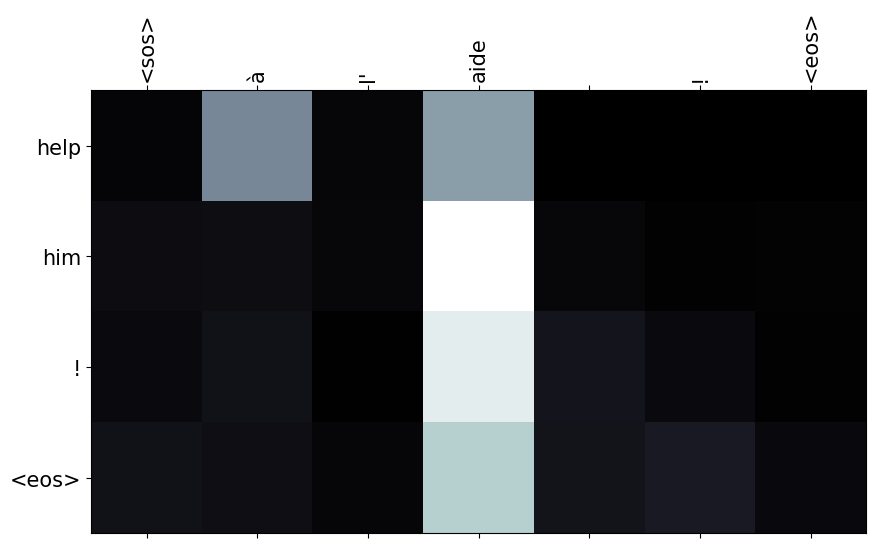

In [77]:
plot_attention(sentence_tokens, translation, attention)

In [83]:
sentence = "Je veux une pomme."

In [84]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    en_nlp,
    fr_nlp,
    en_vocab,
    fr_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [85]:
translation

['<sos>', 'i', 'want', 'an', 'apple', '.', '<eos>']

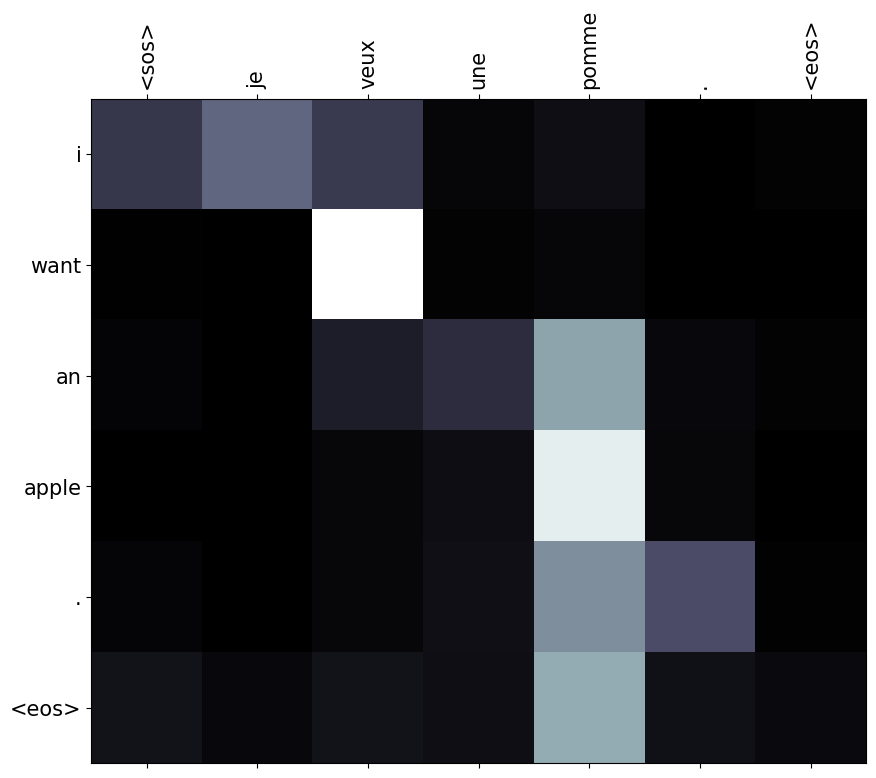

In [86]:
plot_attention(sentence_tokens, translation, attention)

In [87]:
translations = [
    translate_sentence(
        example["fr"],
        model,
        en_nlp,
        fr_nlp,
        en_vocab,
        fr_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )[0]
    for example in tqdm.tqdm(test_data)
]

100%|██████████| 13584/13584 [02:24<00:00, 93.82it/s]


In [88]:
bleu = evaluate.load("bleu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [89]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [90]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [91]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)

In [92]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [93]:
results

{'bleu': 0.5310582035849242,
 'precisions': [0.7663562028027022,
  0.5786726404732647,
  0.46573437280696156,
  0.38509383874552416],
 'brevity_penalty': 1.0,
 'length_ratio': 1.0216248656915794,
 'translation_length': 105541,
 'reference_length': 103307}